In [22]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt


Transforming the images to tensor for PyTorch processing and Load Dataset

In [24]:
transform = transforms.Compose([
    transforms.ToTensor()
])
datasetPath = "/kaggle/input/datasetcnn" 
dataset = torchvision.datasets.ImageFolder(root=datasetPath, transform=transform)

Displaying the basic statistics 


In [25]:
from collections import Counter
import numpy as np
from scipy import stats

numClasses = len(dataset.classes)
numImages = len(dataset)
ClassCounts = Counter(dataset.targets)
classCountVlas = list(ClassCounts.values())
meanCnt = np.mean(classCountVlas)
mdCndt = stats.mode(classCountVlas, keepdims=True).mode[0]
print(f"Dataset contains {numImages} images across {numClasses} classes.")
print(f"Classes: {dataset.classes}")
print(f"Number of images per class: {dict(ClassCounts)}")
print(f"Mean class count: {meanCnt:.2f}")
print(f"Mode of class counts: {mdCndt}")

Dataset contains 30000 images across 3 classes.
Classes: ['dogs', 'food', 'vehicles']
Number of images per class: {0: 10000, 1: 10000, 2: 10000}
Mean class count: 10000.00
Mode of class counts: 10000


Visualization 1 - 3x3 grid sample images

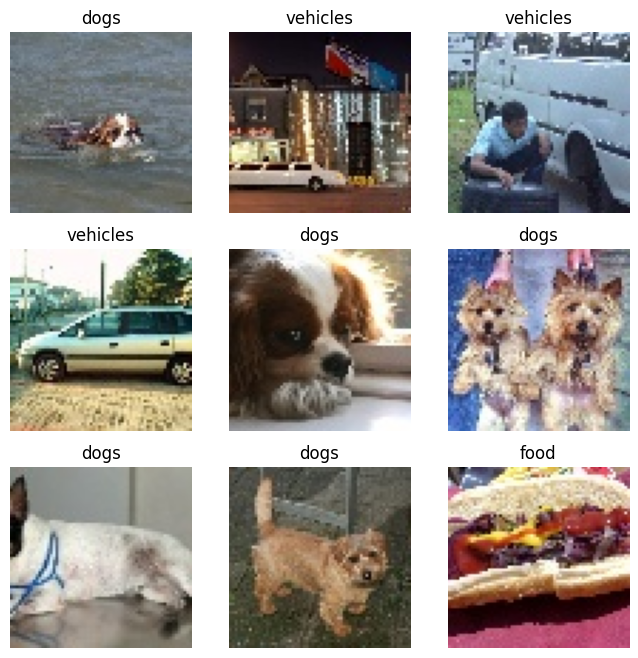

In [26]:
def imshow(img, ax):
    img = img.numpy().transpose((1, 2, 0))
    ax.imshow(img)
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
indices = np.random.choice(len(dataset), 9, replace=False)
for ax, idx in zip(axes.ravel(), indices):
    img, label = dataset[idx]
    imshow(img, ax)
    ax.set_title(dataset.classes[label])
    ax.axis("off")
plt.show()

Visualization 2 - Bar Chart of Image Distribution per Class

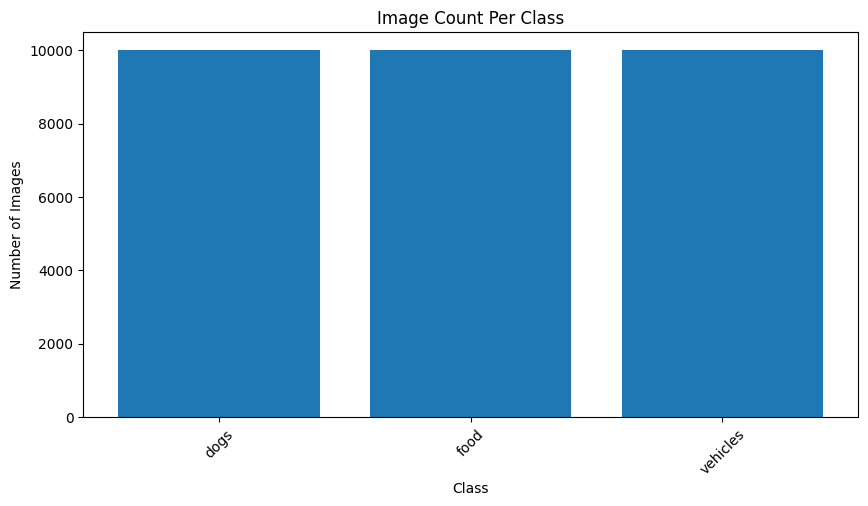

In [27]:
plt.figure(figsize=(10, 5))
plt.bar(ClassCounts.keys(), ClassCounts.values(), tick_label=dataset.classes)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Image Count Per Class")
plt.xticks(rotation=45)
plt.show()

Visualization 3 - Histogram of Pixel Values for a Sample Image

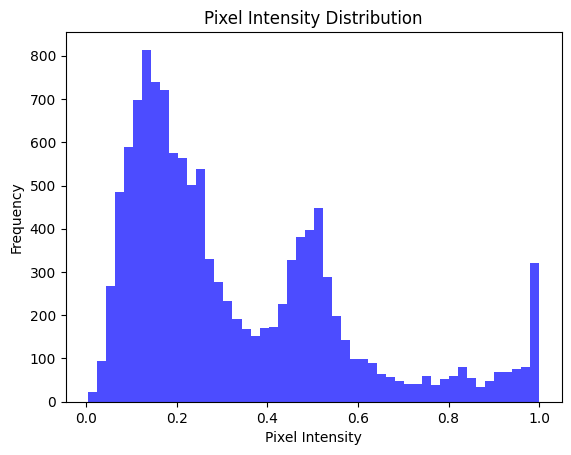

In [28]:
sample_img, _ = dataset[0]  # Take the first image
plt.hist(sample_img.numpy().flatten(), bins=50, color='blue', alpha=0.7)
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("Pixel Intensity Distribution")
plt.show()

Compute and Display the "Average" Image Per Class

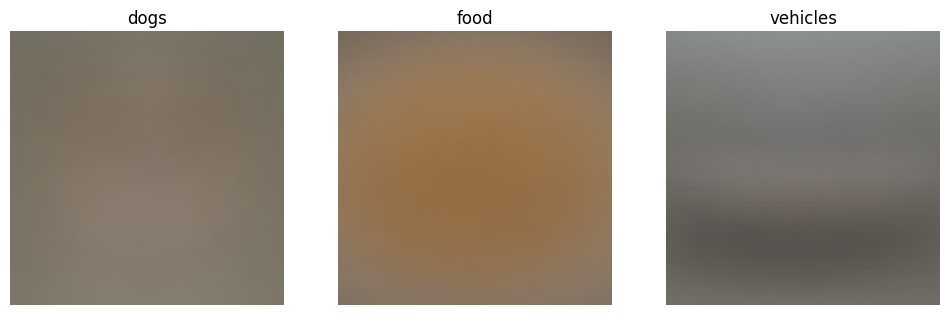

In [29]:
import torch
avgImages = {className: torch.zeros_like(sample_img) for className in dataset.classes}
ClassCounts = {className: 0 for className in dataset.classes}
for img, label in dataset:
    avgImages[dataset.classes[label]] += img
    ClassCounts[dataset.classes[label]] += 1
for className in avgImages.keys():
    avgImages[className] /= ClassCounts[className]
fig, axes = plt.subplots(1, numClasses, figsize=(12, 4))
for ax, (className, avgImg) in zip(axes, avgImages.items()):
    imshow(avgImg, ax)
    ax.set_title(className)
    ax.axis("off")
plt.show()

PreProcessing - Redefining the transformm addition of Normalization and reloading the dataset

In [30]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
dataset = torchvision.datasets.ImageFolder(root=datasetPath, transform=transform)

We are giving more weights to the less common classes to handle class imbalance if there is any imbalance in the data

In [31]:
from torch.utils.data import DataLoader, WeightedRandomSampler
classSampleCountss = np.array(list(ClassCounts.values()))
weights = 1.0 / classSampleCountss
samplesWeights = [weights[t] for t in dataset.targets]
sampler = WeightedRandomSampler(samplesWeights, len(samplesWeights))
trainLoader = DataLoader(dataset, batchSize=32, sampler=sampler)

 Convert Target Labels to Integer Tensors

In [32]:
targets = torch.tensor(dataset.targets, dtype=torch.long)

Split into Training and testing tests and creation of dataLoaders

In [33]:
from sklearn.model_selection import train_test_split
trainIndices, test_indices = train_test_split(range(len(dataset)), test_size=0.2, stratify=dataset.targets)
trainDset = torch.utils.data.Subset(dataset, trainIndices)
testDset = torch.utils.data.Subset(dataset, test_indices)

print(f"Training set: {len(trainDset)} images")
print(f"Testing set: {len(testDset)} images")

trainLoader = DataLoader(trainDset, batchSize=32, shuffle=True)
testLoader = DataLoader(testDset, batchSize=32, shuffle=False)

Training set: 24000 images
Testing set: 6000 images


VGG Model

In [34]:
class VGG16(nn.Module):
    def __init__(self, numClasses=3):
        super(VGG16, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  
            
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, numClasses)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

Defining weight initialization for 2 weights xavier and he to verify which is best fit

In [35]:
def InitializeWts(model, init_type="xavier"):
    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            if init_type == "xavier":
                nn.init.xavier_uniform_(m.weight)
            elif init_type == "he":
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
            elif init_type == "normal":
                nn.init.normal_(m.weight, mean=0.0, std=0.02)

Load Dataset and preparation of dataloaders

In [36]:
trainTransform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

valTransform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

dataset_path = "/kaggle/input/datasetcnn"
trainDset = torchvision.datasets.ImageFolder(root=dataset_path, transform=trainTransform)
valDset = torchvision.datasets.ImageFolder(root=dataset_path, transform=valTransform)
trainSize = int(0.8 * len(trainDset))
valSize = len(trainDset) - trainSize
trainDset, valDset = random_split(trainDset, [trainSize, valSize])
batchSize = 32
trainLoader = DataLoader(trainDset, batchSize=batchSize, shuffle=True)
valLoader = DataLoader(valDset, batchSize=batchSize, shuffle=False)

Defining Early stopping

In [37]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.01):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
    def shouldStop(self, valLoss):
        if valLoss < self.best_loss - self.min_delta:
            self.best_loss = valLoss
            self.counter = 0 
        else:
            self.counter += 1
        return self.counter >= self.patience

Model Training

In [38]:
import time
import torch
def trainVggModel(model, trainLoader, valLoader, optimizer, criterion, scheduler, earlyStopping, epochs=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    bestValAccuracy = 0
    history = {
        'trainAcc': [],
        'valAcc': [],
        'trainLoss': [],
        'valLoss': []
    }
    epochTimes = []
    for epoch in range(epochs):
        startTimes = time.time()
        model.train()
        trainLoss, correct, total = 0, 0, 0
        for images, labels in trainLoader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            trainLoss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
        trainAccuracy = 100 * correct / total
        model.eval()
        valLoss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in valLoader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valLoss += loss.item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)
        valAccuracy = 100 * correct / total
        if valAccuracy > bestValAccuracy:
            bestValAccuracy = valAccuracy
        history['trainLoss'].append(trainLoss / len(trainLoader))
        history['trainAcc'].append(trainAccuracy)
        history['valLoss'].append(valLoss / len(valLoader))
        history['valAcc'].append(valAccuracy)
        scheduler.step(valLoss)
        epochTime = time.time() - startTimes
        epochTimes.append(epochTime)
        if earlyStopping.shouldStop(valLoss):
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
        print(f"Epoch [{epoch+1}/{epochs}]: Train Loss: {trainLoss/len(trainLoader):.4f}, "
              f"Train Acc: {trainAccuracy:.2f}%, Val Loss: {valLoss/len(valLoader):.4f}, "
              f"Val Acc: {valAccuracy:.2f}%, Time: {epochTime:.2f} sec")
    return model, history, bestValAccuracy

In [39]:
import random
wtInitMethods = ["xavier", "he"]
criterion = nn.CrossEntropyLoss()
learningRate = 0.01
bestIniit = None
bestAcc = 0
optimizerHistories={}
for init in wtInitMethods:
    print(f"\nTraining with {init} initialization...\n")
    model = VGG16(numClasses=len(trainDset.dataset.classes))
    InitializeWts(model, init)
    optimizer = optim.SGD(model.parameters(), lr=learningRate, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, verbose=True)
    earlyStopping = EarlyStopping(patience=3, min_delta=0.01)
    trainedModel,history, valAcc = trainVggModel(model, trainLoader, valLoader, optimizer, criterion, scheduler, earlyStopping, epochs=3)
    optimizerHistories[init] = history
    optimizerHistories[init] = {
        'trainAcc': history['trainAcc'],
        'valAcc': history['valAcc'],
        'trainLoss': history['trainLoss'],
        'valLoss': history['valLoss']
    }
    if valAcc > bestAcc:
        bestAcc = valAcc
        bestIniit = init
print(f"Best Weight Initialization: {bestIniit} with {bestAcc}% accuracy")


Training with xavier initialization...



/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/3]: Train Loss: 0.8618, Train Acc: 57.55%, Val Loss: 0.6227, Val Acc: 74.27%, Time: 102.43 sec
Epoch [2/3]: Train Loss: 0.5909, Train Acc: 76.16%, Val Loss: 0.5276, Val Acc: 77.88%, Time: 102.82 sec
Epoch [3/3]: Train Loss: 0.5045, Train Acc: 80.05%, Val Loss: 0.5419, Val Acc: 77.35%, Time: 104.05 sec

Training with he initialization...

Epoch [1/3]: Train Loss: 0.8352, Train Acc: 60.97%, Val Loss: 0.6125, Val Acc: 76.68%, Time: 104.23 sec
Epoch [2/3]: Train Loss: 0.5261, Train Acc: 79.21%, Val Loss: 0.4550, Val Acc: 81.93%, Time: 105.28 sec
Epoch [3/3]: Train Loss: 0.4327, Train Acc: 83.20%, Val Loss: 0.4543, Val Acc: 81.68%, Time: 108.00 sec
Best Weight Initialization: he with 81.93333333333334% accuracy


Test accuracy evaluation for he Model

In [40]:
def modelEvaluation(model, testLoader, criterion):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    correct, total = 0, 0
    testLoss = 0
    with torch.no_grad():
        for images, labels in testLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            testLoss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    accuracy = 100 * correct / total
    avgLosse = testLoss / len(testLoader)
    print(f"Test Loss: {avgLosse:.4f}")
    print(f"Test Accuracy: {accuracy:.2f}%")
    return accuracy

testLoader = valLoader  
modelEvaluation(trainedModel, testLoader, criterion)

Test Loss: 0.4579
Test Accuracy: 81.53%


81.53333333333333

GRAPHS for two different weight initialization

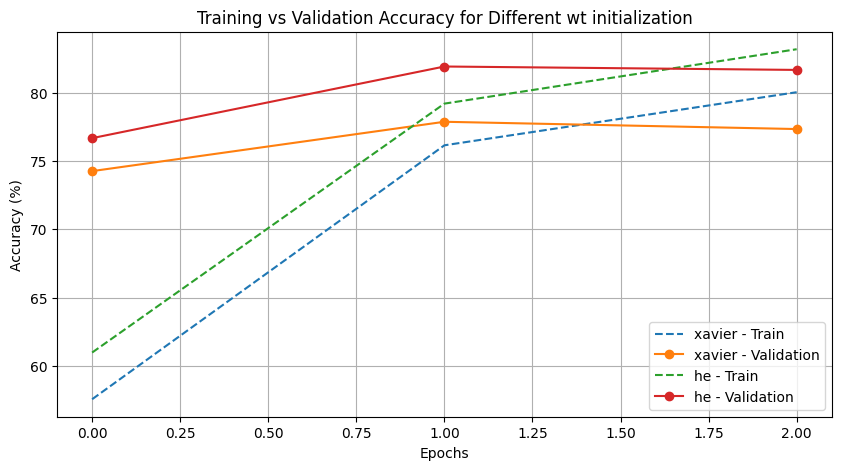

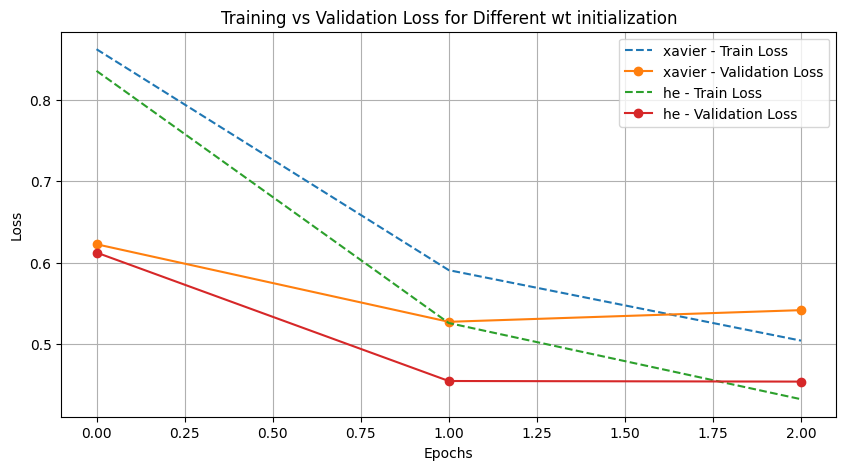

In [41]:
plt.figure(figsize=(10, 5))
for optimizerName, history in optimizerHistories.items():
    plt.plot(history['trainAcc'], label=f'{optimizerName} - Train', linestyle='dashed')
    plt.plot(history['valAcc'], label=f'{optimizerName} - Validation', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training vs Validation Accuracy for Different wt initialization')
plt.grid()
plt.show()
plt.figure(figsize=(10, 5))
for optimizerName, history in optimizerHistories.items():
    plt.plot(history['trainLoss'], label=f'{optimizerName} - Train Loss', linestyle='dashed')
    plt.plot(history['valLoss'], label=f'{optimizerName} - Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss for Different wt initialization')
plt.grid()
plt.show()

confusion Matrix

Test Accuracy: 81.35%, Test Loss: 0.4597


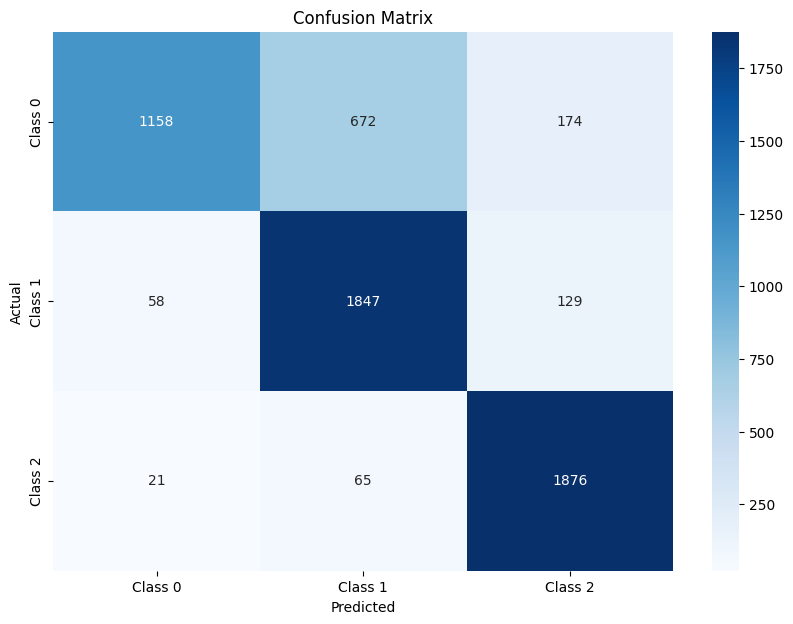

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
def modelEvaluation(model, dataLoader, criterion):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    allPreds, allLabels = [], []
    testLoss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            testLoss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            allPreds.extend(predicted.cpu().numpy())
            allLabels.extend(labels.cpu().numpy())
    testAccuracy = 100 * correct / total
    print(f"Test Accuracy: {testAccuracy:.2f}%, Test Loss: {testLoss / len(dataLoader):.4f}")
    return allPreds, allLabels
testPreds, testLabels = modelEvaluation(trainedModel, testLoader, criterion)
confusionMtrx= confusion_matrix(testLabels, testPreds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classNames, yticklabels=classNames)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

From above we are picking the best weight initialization 'he' and running the same model with 3 different optimizer to see the best fit

In [45]:
class VGG16(nn.Module):
    def __init__(self, numClasses=3):
        super(VGG16, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  
            
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, numClasses)  
        ) 
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

Initialize Weights (He Initialization)

In [46]:
def InitializeWts(model, init_type="he"):
    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            if init_type == "he":
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')

Data Augmentation and Loading

In [47]:
trainTransform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
valTransform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
dataset_path = "/kaggle/input/datasetcnn"
trainDset = torchvision.datasets.ImageFolder(root=dataset_path, transform=trainTransform)
valDset = torchvision.datasets.ImageFolder(root=dataset_path, transform=valTransform)
trainSize = int(0.8 * len(trainDset))
valSize = len(trainDset) - trainSize
trainDset, valDset = random_split(trainDset, [trainSize, valSize])
batchSize = 32
trainLoader = DataLoader(trainDset, batchSize=batchSize, shuffle=True)
valLoader = DataLoader(valDset, batchSize=batchSize, shuffle=False)

Define Early Stopping Mechanism

In [48]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.01):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
    def shouldStop(self, valLoss):
        if valLoss < self.best_loss - self.min_delta:
            self.best_loss = valLoss
            self.counter = 0
        else:
            self.counter += 1

        return self.counter >= self.patience

 Train the Model Function with Early Stopping

In [49]:
import time
import torch
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
def trainVggModel(model, trainLoader, valLoader, optimizer, criterion, scheduler, earlyStopping, epochs=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    history = {
        'trainAcc': [],
        'valAcc': [],
        'trainLoss': [],
        'valLoss': []
    }
    epochTimes = []  
    for epoch in range(epochs):
        startTimes = time.time()  
        model.train()
        trainLoss, correct, total = 0, 0, 0
        for images, labels in trainLoader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            trainLoss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
        trainAccuracy = 100 * correct / total
        model.eval()
        valLoss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in valLoader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valLoss += loss.item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)
        valAccuracy = 100 * correct / total
        history['trainLoss'].append(trainLoss / len(trainLoader))
        history['trainAcc'].append(trainAccuracy)
        history['valLoss'].append(valLoss / len(valLoader))
        history['valAcc'].append(valAccuracy)
        scheduler.step(valLoss)
        epochTime = time.time() - startTimes
        epochTimes.append(epochTime)
        if earlyStopping.shouldStop(valLoss):
            print(f"Early stopping triggered at epoch {epoch+1} (Time: {epochTime:.2f} seconds)")
            break
        print(f"Epoch [{epoch+1}/{epochs}]: Train Loss: {trainLoss/len(trainLoader):.4f}, "
              f"Train Acc: {trainAccuracy:.2f}%, Val Loss: {valLoss/len(valLoader):.4f}, "
              f"Val Acc: {valAccuracy:.2f}%, Time: {epochTime:.2f} sec")
    return model, epochTimes, history

Define and Train the Model Using 3 Optimizers - SGD, Adam, RMSprop

In [51]:
import random
init_method = "he"  
criterion = nn.CrossEntropyLoss()
learningRate = 0.01  
optimizerHistories = {}  
optimizer_methods = {
    "SGD": optim.SGD,
    "Adam": optim.Adam,
    "RMSprop": optim.RMSprop
}
for optimizerName, optimizer_class in optimizer_methods.items():
    print(f"\nTraining with {optimizerName} optimizer...\n")
    model = VGG16(numClasses=len(trainDset.dataset.classes))
    InitializeWts(model, init_method)
    if optimizerName in ["SGD", "RMSprop"]:
        optimizer = optimizer_class(model.parameters(), lr=learningRate, momentum=0.9, weight_decay=5e-4)
    else:
        optimizer = optimizer_class(model.parameters(), lr=learningRate, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, verbose=True)
    earlyStopping = EarlyStopping(patience=3, min_delta=0.01)
    startTimes = time.time()
    trainedModel, epochTimes, history = trainVggModel(model, trainLoader, valLoader, optimizer, criterion, scheduler, earlyStopping, epochs=3)
    if isinstance(history, dict):
        optimizerHistories[optimizerName] = history
    else:
        print(f"Unexpected format for history: {type(history)} - {history}")
    totalTime = time.time() - startTimes
    epochTimes = [float(t) for t in epochTimes]
    print(f"\nEpoch-wise Training Times for {optimizerName}:")
    for i, t in enumerate(epochTimes, 1):
        print(f"  Epoch {i}: {t:.2f} seconds")
    print(f"\nTotal training time for {optimizerName}: {totalTime:.2f} seconds")
    valAcc = max(optimizerHistories[optimizerName]['valAcc'], default=0)
    print(f"\nBest validation accuracy with {optimizerName}: {valAcc:.2f}%")


Training with SGD optimizer...

Epoch [1/3]: Train Loss: 0.8501, Train Acc: 58.87%, Val Loss: 0.5510, Val Acc: 77.48%, Time: 103.90 sec
Epoch [2/3]: Train Loss: 0.5328, Train Acc: 78.88%, Val Loss: 0.5903, Val Acc: 78.55%, Time: 111.56 sec
Epoch [3/3]: Train Loss: 0.4252, Train Acc: 84.03%, Val Loss: 0.4775, Val Acc: 81.65%, Time: 108.21 sec

Epoch-wise Training Times for SGD:
  Epoch 1: 103.90 seconds
  Epoch 2: 111.56 seconds
  Epoch 3: 108.21 seconds

Total training time for SGD: 323.83 seconds

Best validation accuracy with SGD: 81.65%

Training with Adam optimizer...

Epoch [1/3]: Train Loss: 557785137.6350, Train Acc: 33.08%, Val Loss: 1.1014, Val Acc: 33.27%, Time: 123.59 sec
Epoch [2/3]: Train Loss: 316578524.7731, Train Acc: 33.27%, Val Loss: 1.4431, Val Acc: 33.27%, Time: 119.47 sec
Epoch [3/3]: Train Loss: 443723774.6969, Train Acc: 33.18%, Val Loss: 1.1415, Val Acc: 33.27%, Time: 119.28 sec

Epoch-wise Training Times for Adam:
  Epoch 1: 123.59 seconds
  Epoch 2: 119.47 se

test accuracy evaluation

In [52]:
def modelEvaluation(model, testLoader, criterion):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    correct, total = 0, 0
    testLoss = 0
    with torch.no_grad():
        for images, labels in testLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            testLoss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    accuracy = 100 * correct / total
    avgLosse = testLoss / len(testLoader)
    print(f"Test Loss: {avgLosse:.4f}")
    print(f"Test Accuracy: {accuracy:.2f}%")
    return accuracy

In [53]:
testLoader = valLoader 
modelEvaluation(trainedModel, testLoader, criterion)

Test Loss: nan
Test Accuracy: 32.88%


32.88333333333333

GRAPHS for 3 different optimizer while keeping he as weight initializer

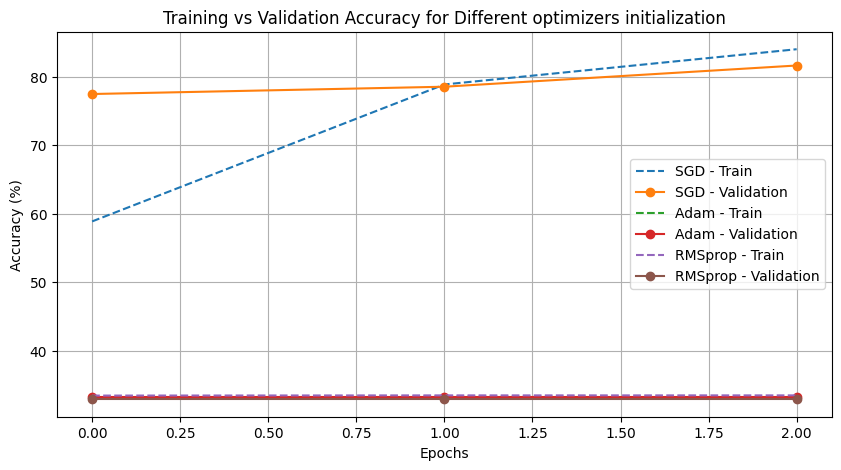

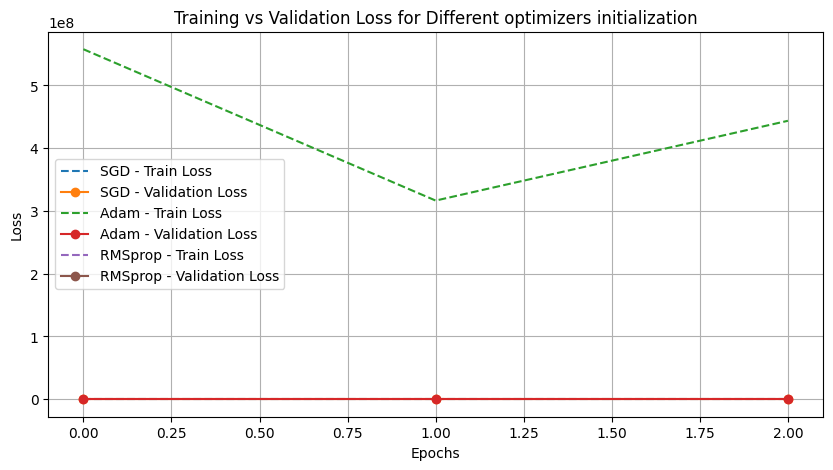

In [54]:
plt.figure(figsize=(10, 5))
for optimizerName, history in optimizerHistories.items():
    plt.plot(history['trainAcc'], label=f'{optimizerName} - Train', linestyle='dashed')
    plt.plot(history['valAcc'], label=f'{optimizerName} - Validation', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training vs Validation Accuracy for Different optimizers initialization')
plt.grid()
plt.show()
plt.figure(figsize=(10, 5))
for optimizerName, history in optimizerHistories.items():
    plt.plot(history['trainLoss'], label=f'{optimizerName} - Train Loss', linestyle='dashed')
    plt.plot(history['valLoss'], label=f'{optimizerName} - Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss for Different optimizers initialization')
plt.grid()
plt.show()

Confusion Matrix for the last model only predicts the class 0 ignoring class 1 and class 2, due to training issues.  From the epochs we can see that the accuracy is high for SDM optimizer.

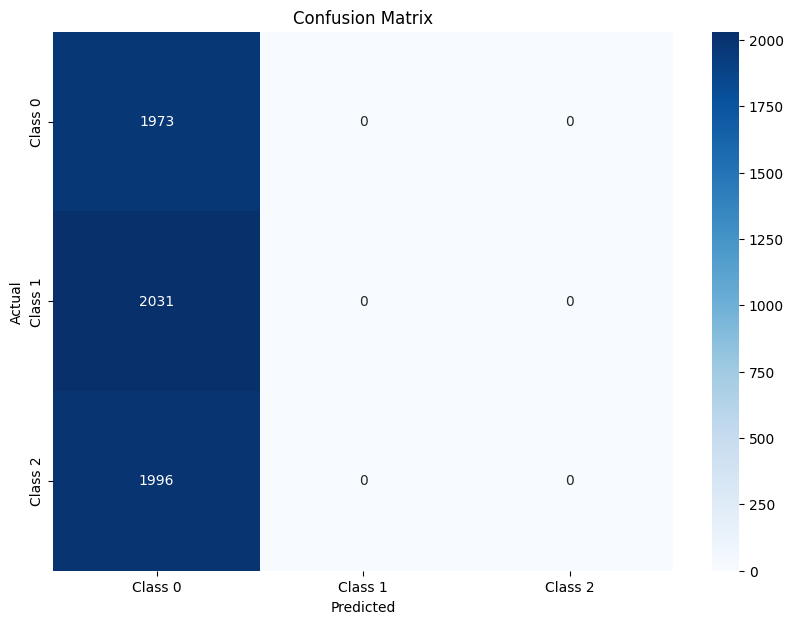

In [55]:
def evaluateModelGraph(model, dataloader, criterion, device='cuda'):
    model.to(device)
    model.eval() 
    allPreds = []
    allLabels = []
    total_loss = 0.0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            allPreds.extend(preds.cpu().numpy())
            allLabels.extend(labels.cpu().numpy())

    return allPreds, allLabels 
testPreds, testLabels = evaluateModelGraph(trainedModel, testLoader, criterion)
if not isinstance(testPreds, list) or not isinstance(testLabels, list):
    raise TypeError("modelEvaluation() should return two lists: testPreds and testLabels")
confusionMtrx= confusion_matrix(testLabels, testPreds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classNames, yticklabels=classNames)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Keeping the optimizer as SGD, He as the weight initialization we are going to verify for batch 32, 64 to see the best fit for our model

In [57]:
class VGG16(nn.Module):
    def __init__(self, numClasses=3):
        super(VGG16, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))  
        
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, numClasses) 
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


he initialization

In [58]:
def InitializeWts(model, init_type="he"):
    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            if init_type == "he":
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')


In [59]:
trainTransform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

valTransform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

datasetPath = "/kaggle/input/datasetcnn"
trainDset = torchvision.datasets.ImageFolder(root=datasetPath, transform=trainTransform)
valDset = torchvision.datasets.ImageFolder(root=datasetPath, transform=valTransform)
trainSize = int(0.8 * len(trainDset))
valSize = len(trainDset) - trainSize
trainDset, valDset = random_split(trainDset, [trainSize, valSize])
batchSize = 64
trainLoader = DataLoader(trainDset, batchSize=batchSize, shuffle=True)
valLoader = DataLoader(valDset, batchSize=batchSize, shuffle=False)

In [60]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.01):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
    def shouldStop(self, valLoss):
        if valLoss < self.best_loss - self.min_delta:
            self.best_loss = valLoss
            self.counter = 0  
        else:
            self.counter += 1  

        return self.counter >= self.patience

In [66]:
import time
import torch

def trainVggModel(model, trainLoader, valLoader, optimizer, criterion, scheduler, earlyStopping, batchSize, epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    epochTimes = []
    history = {"trainAcc": [], "valAcc": [], "trainLoss": [], "valLoss": []}

    for epoch in range(epochs):
        startTimes = time.time()
        model.train()
        trainLoss, correct, total = 0, 0, 0
        for images, labels in trainLoader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            trainLoss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
        trainAccuracy = 100 * correct / total
        history["trainAcc"].append(trainAccuracy)
        history["trainLoss"].append(trainLoss / len(trainLoader))
        model.eval()
        valLoss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in valLoader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valLoss += loss.item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)

        valAccuracy = 100 * correct / total
        history["valAcc"].append(valAccuracy)
        history["valLoss"].append(valLoss / len(valLoader))
        scheduler.step(valLoss)
        epochTime = time.time() - startTimes
        epochTimes.append(epochTime)
        if earlyStopping.shouldStop(valLoss):
            print(f"Early stopping triggered at epoch {epoch+1} (Time: {epochTime:.2f} seconds)")
            break

        print(f"Batch Size [{batchSize}] - Epoch [{epoch+1}/{epochs}]: Train Loss: {history['trainLoss'][-1]:.4f}, "
              f"Train Acc: {trainAccuracy:.2f}%, Val Loss: {history['valLoss'][-1]:.4f}, "
              f"Val Acc: {valAccuracy:.2f}%, Time: {epochTime:.2f} sec")

    return model, epochTimes, history

In [67]:
import torch.optim as optim
import torch.nn as nn

import random
criterion = nn.CrossEntropyLoss()
learningRate = 0.01 
optimizerName = "SGD"
batchSizes = [32, 64]
optimizerHistories = {}

for batchSize in batchSizes:
    print(f"\nTraining with {optimizerName} optimizer and batch size {batchSize}...\n")
    model = VGG16(numClasses=len(trainDset.dataset.classes))
    InitializeWts(model, init_method)
    optimizer = optim.SGD(model.parameters(), lr=learningRate, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, verbose=True)
    earlyStopping = EarlyStopping(patience=3, min_delta=0.01)
    startTimes = time.time()
    trainedModel, epochTimes, history = trainVggModel(model, trainLoader, valLoader, optimizer, criterion, scheduler, earlyStopping, batchSize, epochs=2)
    totalTime = time.time() - startTimes
    print(f"\nTotal training time for batch size {batchSize}: {totalTime:.2f} seconds")
    optimizerHistories[f"{optimizerName}_batch{batchSize}"] = history


Training with SGD optimizer and batch size 32...

Batch Size [32] - Epoch [1/2]: Train Loss: 0.7427, Train Acc: 66.46%, Val Loss: 0.5136, Val Acc: 78.53%, Time: 92.81 sec
Batch Size [32] - Epoch [2/2]: Train Loss: 0.4601, Train Acc: 81.82%, Val Loss: 0.4044, Val Acc: 84.33%, Time: 93.43 sec

Total training time for batch size 32: 186.41 seconds

Training with SGD optimizer and batch size 64...

Batch Size [64] - Epoch [1/2]: Train Loss: 0.7919, Train Acc: 63.70%, Val Loss: 0.6177, Val Acc: 74.07%, Time: 92.26 sec
Batch Size [64] - Epoch [2/2]: Train Loss: 0.5100, Train Acc: 79.80%, Val Loss: 0.4323, Val Acc: 84.20%, Time: 93.57 sec

Total training time for batch size 64: 185.98 seconds


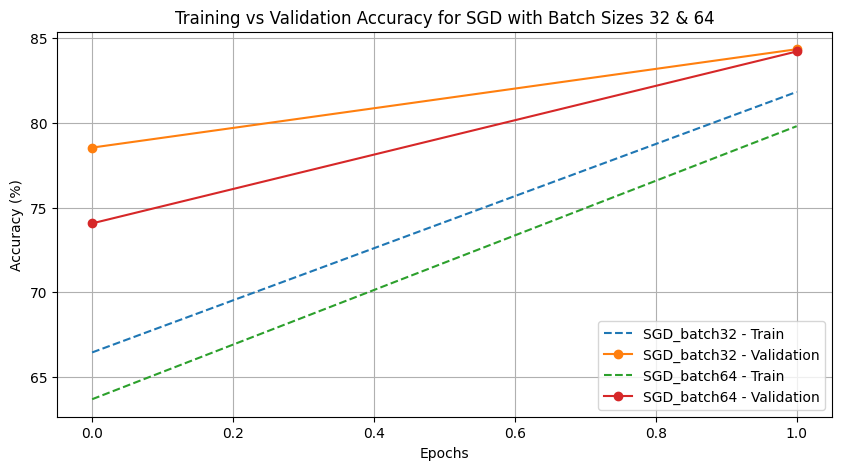

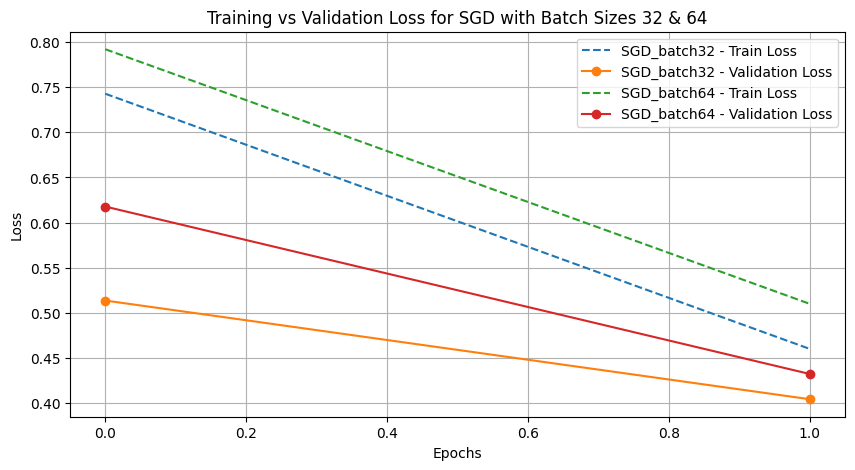

In [68]:
plt.figure(figsize=(10, 5))
for key, history in optimizerHistories.items():
    plt.plot(history['trainAcc'], label=f'{key} - Train', linestyle='dashed')
    plt.plot(history['valAcc'], label=f'{key} - Validation', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training vs Validation Accuracy for SGD with Batch Sizes 32 & 64')
plt.grid()
plt.show
plt.figure(figsize=(10, 5))
for key, history in optimizerHistories.items():
    plt.plot(history['trainLoss'], label=f'{key} - Train Loss', linestyle='dashed')
    plt.plot(history['valLoss'], label=f'{key} - Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss for SGD with Batch Sizes 32 & 64')
plt.grid()
plt.show()

From the epochs and the above graphs and the confusion matrix we can conclude that batch size 32 is the best fit because it can generalize better, avoid overfitting and provides smoother updates and can perform better on limited memory systems compared to batch size 64

Test Accuracy: 84.00%, Test Loss: 0.4384


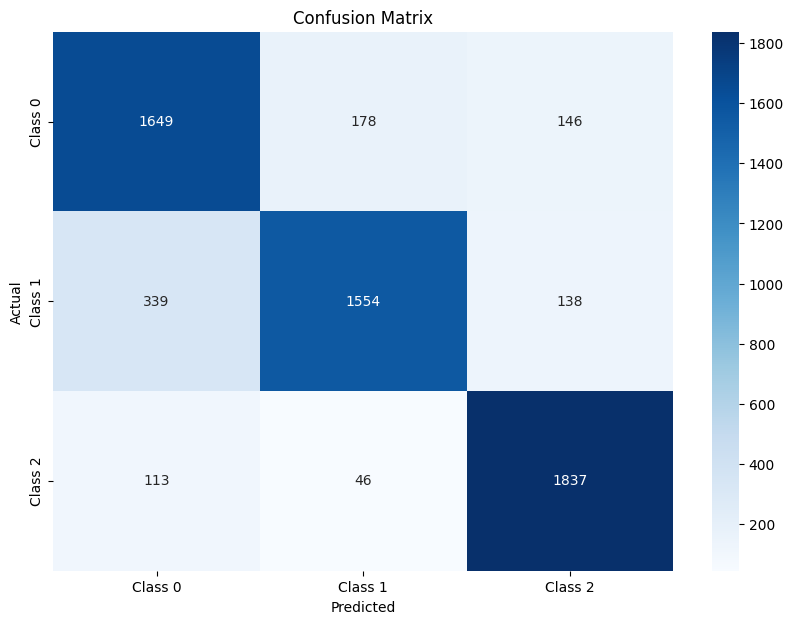

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
def modelEvaluation(model, dataLoader, criterion):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    allPreds, allLabels = [], []
    testLoss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            testLoss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            allPreds.extend(predicted.cpu().numpy())
            allLabels.extend(labels.cpu().numpy())
    testAccuracy = 100 * correct / total
    print(f"Test Accuracy: {testAccuracy:.2f}%, Test Loss: {testLoss / len(dataLoader):.4f}")
    return allPreds, allLabels
testPreds, testLabels = modelEvaluation(trainedModel, testLoader, criterion)
confusionMtrx= confusion_matrix(testLabels, testPreds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classNames, yticklabels=classNames)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Best model derived from the model combinations specified above <br>
Optimizer - SGD<br>
weight Initialization- he<br>
Batch size - 32<br>

In [70]:
class VGG16(nn.Module):
    def __init__(self, numClasses=3):
        super(VGG16, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  
            
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  
            
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))  
        
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, numClasses)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [71]:
def InitializeWts(model, init_type="xavier"):
    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            if init_type == "xavier":
                nn.init.xavier_uniform_(m.weight)
            elif init_type == "he":
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
            elif init_type == "normal":
                nn.init.normal_(m.weight, mean=0.0, std=0.02)

In [72]:
trainTransform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
valTransform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
datasetPath = "/kaggle/input/datasetcnn"
trainDset = torchvision.datasets.ImageFolder(root=datasetPath, transform=trainTransform)
valDset = torchvision.datasets.ImageFolder(root=datasetPath, transform=valTransform)
trainSize = int(0.8 * len(trainDset))
valSize = len(trainDset) - trainSize
trainDset, valDset = random_split(trainDset, [trainSize, valSize])
batchSize = 32
trainLoader = DataLoader(trainDset, batchSize=batchSize, shuffle=True)
valLoader = DataLoader(valDset, batchSize=batchSize, shuffle=False)

In [73]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.01):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
    def shouldStop(self, valLoss):
        if valLoss < self.best_loss - self.min_delta:
            self.best_loss = valLoss
            self.counter = 0 
        else:
            self.counter += 1
        return self.counter >= self.patience

In [74]:
import time
import torch
def trainVggModel(model, trainLoader, valLoader, optimizer, criterion, scheduler, earlyStopping, epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    bestValAccuracy = 0
    history = {
        'trainAcc': [],
        'valAcc': [],
        'trainLoss': [],
        'valLoss': []
    }
    epochTimes = []  
    for epoch in range(epochs):
        startTimes = time.time()
        model.train()
        trainLoss, correct, total = 0, 0, 0
        for images, labels in trainLoader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            trainLoss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
        trainAccuracy = 100 * correct / total
        model.eval()
        valLoss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in valLoader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valLoss += loss.item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)
        valAccuracy = 100 * correct / total
        if valAccuracy > bestValAccuracy:
            bestValAccuracy = valAccuracy
        history['trainLoss'].append(trainLoss / len(trainLoader))
        history['trainAcc'].append(trainAccuracy)
        history['valLoss'].append(valLoss / len(valLoader))
        history['valAcc'].append(valAccuracy)
        scheduler.step(valLoss)
        epochTime = time.time() - startTimes
        epochTimes.append(epochTime)
        if earlyStopping.shouldStop(valLoss):
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

        print(f"Epoch [{epoch+1}/{epochs}]: Train Loss: {trainLoss/len(trainLoader):.4f}, "
              f"Train Acc: {trainAccuracy:.2f}%, Val Loss: {valLoss/len(valLoader):.4f}, "
              f"Val Acc: {valAccuracy:.2f}%, Time: {epochTime:.2f} sec")
    return model, history, bestValAccuracy  

In [75]:
import random
wtInitMethods = ["he"]
criterion = nn.CrossEntropyLoss()
learningRate = 0.01
bestIniit = None
bestAcc = 0
optimizerHistories={}
for init in wtInitMethods:
    print(f"\nTraining with {init} initialization...\n")
    model = VGG16(numClasses=len(trainDset.dataset.classes))
    InitializeWts(model, init)
    optimizer = optim.SGD(model.parameters(), lr=learningRate, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, verbose=True)
    earlyStopping = EarlyStopping(patience=3, min_delta=0.01)
    trainedModel,history, valAcc = trainVggModel(model, trainLoader, valLoader, optimizer, criterion, scheduler, earlyStopping, epochs=5)
    optimizerHistories[init] = history
    optimizerHistories[init] = {
        'trainAcc': history['trainAcc'],
        'valAcc': history['valAcc'],
        'trainLoss': history['trainLoss'],
        'valLoss': history['valLoss']
    }
    if valAcc > bestAcc:
        bestAcc = valAcc
        bestIniit = init
print(f"Best Weight Initialization: {bestIniit} with {bestAcc}% accuracy")


Training with he initialization...



/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/5]: Train Loss: 0.8863, Train Acc: 55.95%, Val Loss: 0.6377, Val Acc: 76.15%, Time: 103.03 sec
Epoch [2/5]: Train Loss: 0.5203, Train Acc: 79.65%, Val Loss: 0.4598, Val Acc: 81.67%, Time: 103.01 sec
Epoch [3/5]: Train Loss: 0.4174, Train Acc: 84.14%, Val Loss: 0.3663, Val Acc: 86.42%, Time: 102.02 sec
Epoch [4/5]: Train Loss: 0.3497, Train Acc: 87.15%, Val Loss: 0.3540, Val Acc: 87.65%, Time: 102.74 sec
Epoch [5/5]: Train Loss: 0.3124, Train Acc: 88.48%, Val Loss: 0.3379, Val Acc: 87.43%, Time: 103.11 sec
Best Weight Initialization: he with 87.65% accuracy


In [77]:
def modelEvaluation(model, testLoader, criterion):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    correct, total = 0, 0
    testLoss = 0
    with torch.no_grad():
        for images, labels in testLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            testLoss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    accuracy = 100 * correct / total
    avgLosse = testLoss / len(testLoader)
    print(f"Test Loss: {avgLosse:.4f}")
    print(f"Test Accuracy: {accuracy:.2f}%")
testLoader = valLoader 
modelEvaluation(trainedModel, testLoader, criterion)

Test Loss: 0.3294
Test Accuracy: 87.55%


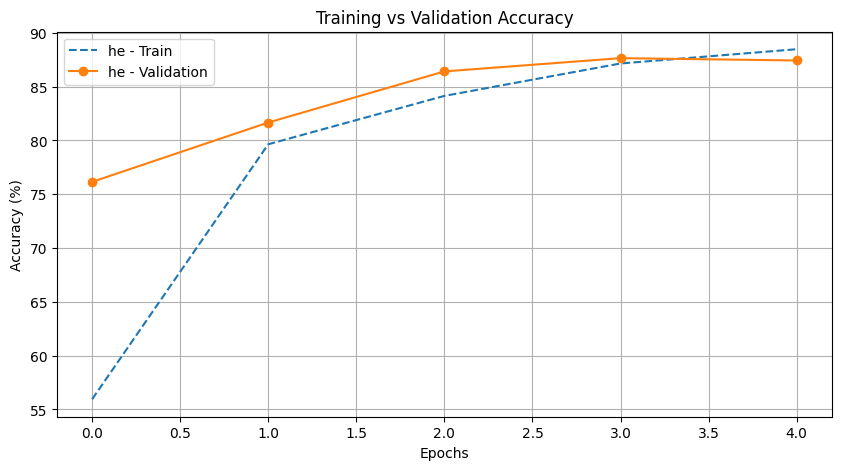

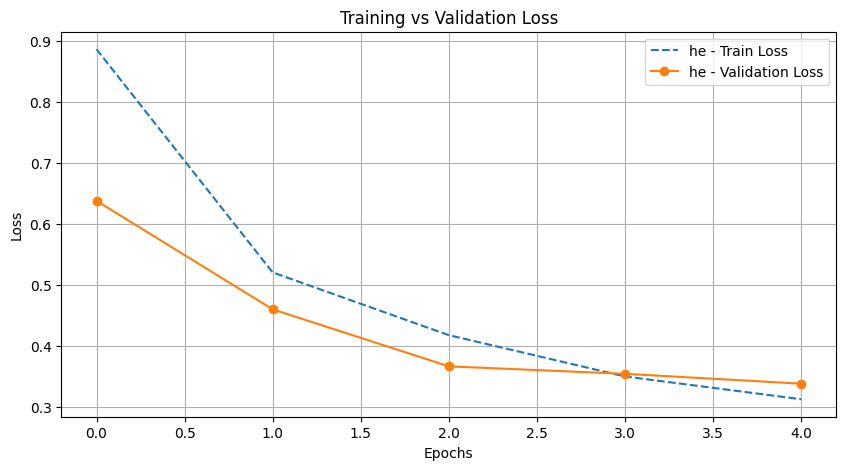

In [78]:
plt.figure(figsize=(10, 5))
for optimizerName, history in optimizerHistories.items():
    plt.plot(history['trainAcc'], label=f'{optimizerName} - Train', linestyle='dashed')
    plt.plot(history['valAcc'], label=f'{optimizerName} - Validation', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.grid()
plt.show()
plt.figure(figsize=(10, 5))
for optimizerName, history in optimizerHistories.items():
    plt.plot(history['trainLoss'], label=f'{optimizerName} - Train Loss', linestyle='dashed')
    plt.plot(history['valLoss'], label=f'{optimizerName} - Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.grid()
plt.show()


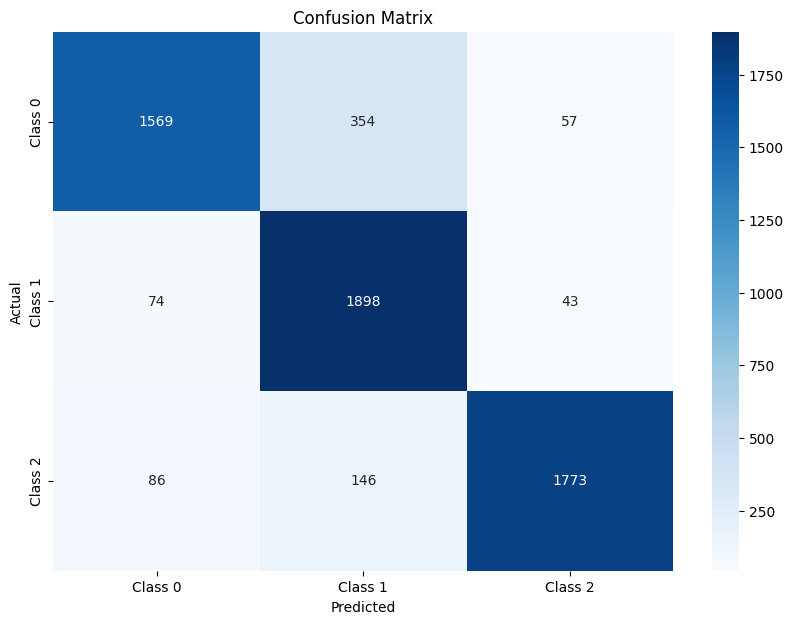

In [79]:
def evaluateModelGraph(model, dataloader, criterion, device='cuda'):
    model.to(device)  
    model.eval() 
    allPreds = []
    allLabels = []
    total_loss = 0.0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device) 
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)  
            allPreds.extend(preds.cpu().numpy())  
            allLabels.extend(labels.cpu().numpy())  
    return allPreds, allLabels  
testPreds, testLabels = evaluateModelGraph(trainedModel, testLoader, criterion)
if not isinstance(testPreds, list) or not isinstance(testLabels, list):
    raise TypeError("modelEvaluation() should return two lists: testPreds and testLabels")
confusionMtrx= confusion_matrix(testLabels, testPreds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classNames, yticklabels=classNames)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [81]:
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, _ = precision_recall_fscore_support(testLabels, testPreds, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

Precision: 0.8816, Recall: 0.8733, F1 Score: 0.8736


From the above outputs for the best model we can conclude that: <br>
He initialization performed best achieving around 87.65% validation accuracy <br>
Training and validation improved graduallly with less overfitting<br>
The Loss decreased consistently indicating that the model has good convergence<br>
The confusion matrix shows a reasonable class wise balance although class 0 has higher misclassifications<br>
from the precision, Recall and F1 score indicates a well balanced and better performing model.

Display of few misclassified images from the test set along with their true labels - Misclassification could be due to <br>
Low image quality - The model could not recognize since the objects in th images is not clear <br>
Similarity of the classes - certain images look alike which confuses the model <br>
Weak learning of the feature -  The model might not have picked the right features to differentiate between the classes apart

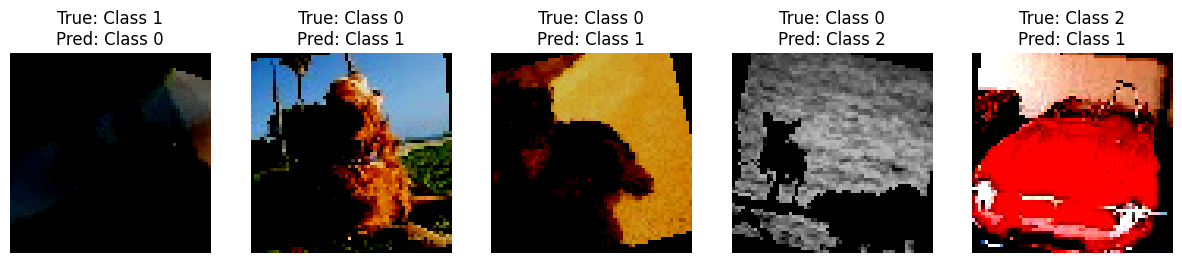

In [82]:
misclassifiedIndices = [i for i in range(len(testLabels)) if testLabels[i] != testPreds[i]]
misclassifiedImages = [testLoader.dataset[i][0] for i in misclassifiedIndices[:5]]
trueLabels = [classNames[testLabels[i]] for i in misclassifiedIndices[:5]]
predLabels = [classNames[testPreds[i]] for i in misclassifiedIndices[:5]]
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for idx, ax in enumerate(axes):
    ax.imshow(misclassifiedImages[idx].permute(1, 2, 0))
    ax.set_title(f"True: {trueLabels[idx]}\nPred: {predLabels[idx]}")
    ax.axis('off')
plt.show()

In [83]:
torch.save(model.state_dict(), "a1_part1_rsaravan_kisorese_wt.pt")